In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("diabetes.txt", sep="\t")

# séparation features / label
X = data.iloc[:, :-1].values   # 8 dimensions
y = data.iloc[:, -1].values

In [3]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
X_diabetic = X[y == 1]
X_non_diabetic = X[y == 0]

In [5]:
def pca_dimensions(X):
    # mean
    mu = np.mean(X, axis=0)

    # center the data
    X_centered = X - mu

    # number of original dimensions
    p = X_centered.shape[1]

    # covariance matrix
    Sigma = (X_centered.T @ X_centered) / X_centered.shape[0]

    # eigen decomposition
    # eigh is better here because Sigma is symmetric
    eigenvalues, eigenvectors = np.linalg.eigh(Sigma)

    # sort from largest to smallest
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # explained variance
    percent = 100 * eigenvalues / np.sum(eigenvalues)
    cumpercent = np.cumsum(percent)

    columns = [
        "eigenvalue",
        "explained variance (%)",
        "cumulative explained variance (%)"
    ]
    index = [f"Dim.{i+1}" for i in range(p)]

    Eigen = pd.DataFrame(
        np.column_stack((eigenvalues, percent, cumpercent)),
        index=index,
        columns=columns
    )
    Eigen.index.name = "Dimension"

    return mu, X_centered, Sigma, Eigen, eigenvalues, eigenvectors


In [14]:
def pca_compute(X_centered, eigenvectors, P):
    U = eigenvectors[:, :P]
    Y = X_centered @ U
    return Y, U

In [15]:
mu_d, Xc_d, Sigma_d, Eigen_d, eigenvalues_d, eigenvectors_d = pca_dimensions(X_diabetic)

In [23]:
print("DIABETIC GROUP")

print("\nEigenvalue table:")
print(Eigen_d.round(2))

DIABETIC GROUP

Eigenvalue table:
           eigenvalue  explained variance (%)  \
Dimension                                       
Dim.1        19305.60                   91.33   
Dim.2          949.74                    4.49   
Dim.3          485.92                    2.30   
Dim.4          237.33                    1.12   
Dim.5          105.32                    0.50   
Dim.6           42.64                    0.20   
Dim.7           10.63                    0.05   
Dim.8            0.13                    0.00   

           cumulative explained variance (%)  
Dimension                                     
Dim.1                                  91.33  
Dim.2                                  95.83  
Dim.3                                  98.13  
Dim.4                                  99.25  
Dim.5                                  99.75  
Dim.6                                  99.95  
Dim.7                                 100.00  
Dim.8                                 100.00  


In [26]:
Y_d, U_d = pca_compute(Xc_d, eigenvectors_d, P=3)

In [27]:
mu_nd, Xc_nd, Sigma_nd, Eigen_nd, eigenvalues_nd, eigenvectors_nd = pca_dimensions(X_non_diabetic)

In [28]:
print("\n\n NON-DIABETIC GROUP")
print("Original shape:", X_non_diabetic.shape)
print("\nEigenvalue table:")
print(Eigen_nd.round(2))





 NON-DIABETIC GROUP
Original shape: (500, 8)

Eigenvalue table:
           eigenvalue  explained variance (%)  \
Dimension                                       
Dim.1         9892.12                   88.42   
Dim.2          635.72                    5.68   
Dim.3          335.51                    3.00   
Dim.4          168.80                    1.51   
Dim.5          109.70                    0.98   
Dim.6           39.86                    0.36   
Dim.7            5.94                    0.05   
Dim.8            0.08                    0.00   

           cumulative explained variance (%)  
Dimension                                     
Dim.1                                  88.42  
Dim.2                                  94.10  
Dim.3                                  97.10  
Dim.4                                  98.61  
Dim.5                                  99.59  
Dim.6                                  99.95  
Dim.7                                 100.00  
Dim.8               

In [29]:
Y_nd, U_nd = pca_compute(Xc_nd, eigenvectors_nd, P=3)

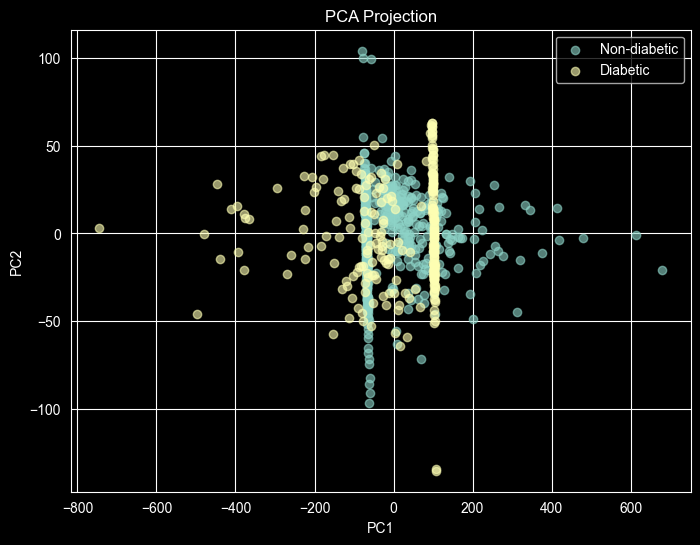

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_nd[:, 0], Y_nd[:, 1], alpha=0.6, label="Non-diabetic")
plt.scatter(Y_d[:, 0], Y_d[:, 1], alpha=0.6, label="Diabetic")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.legend()
plt.grid(True)
plt.show()

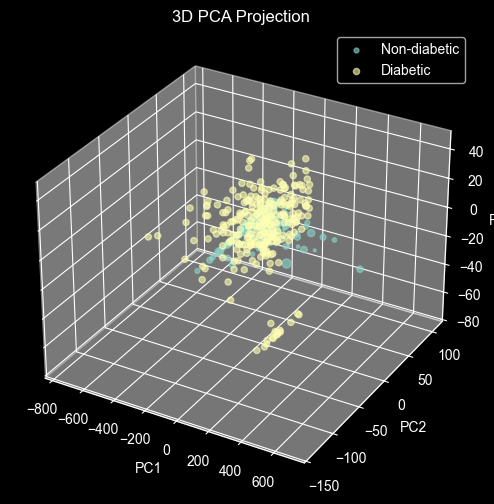

In [31]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

plt.scatter(Y_nd[:, 0], Y_nd[:, 1],Y_nd[:, 2], alpha=0.6, label='Non-diabetic')
ax.scatter(Y_d[:, 0], Y_d[:, 1], Y_d[:, 2], alpha=0.6, label='Diabetic')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection")
ax.legend()
plt.grid(True)
plt.show()